# Investigation of muscle oxygen consumption on an exhaustive analytical muscle exercise at different intensities

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from IPython.display import Image
from scipy.integrate import simpson

## Protocol outline
Exercise: Biceps curl.

Sets: @ 50 -> 70 -> 30 -> 90 -> 10 %.

Rest: 7 min between sets.

RM determination beforehand (10 min before the protocol start).

Standardisation: elbows not in front of the thorax, hips and shoulder blades touching the wall, straight legs with feet several cm in front (the back is resting on the wall), bar reaching half of the thigh (down) and nipples' line for a validated repetition.

Limitations: 
- no control for execution speed,
- no control for psychological exhaustion,
- no precise timing of sets (could have been done with the accelerometry data of the other sensor).

In [76]:
# Integrate image (.jpeg) of session's info in notebook
Image(url="session.jpeg", width=800, height=600)

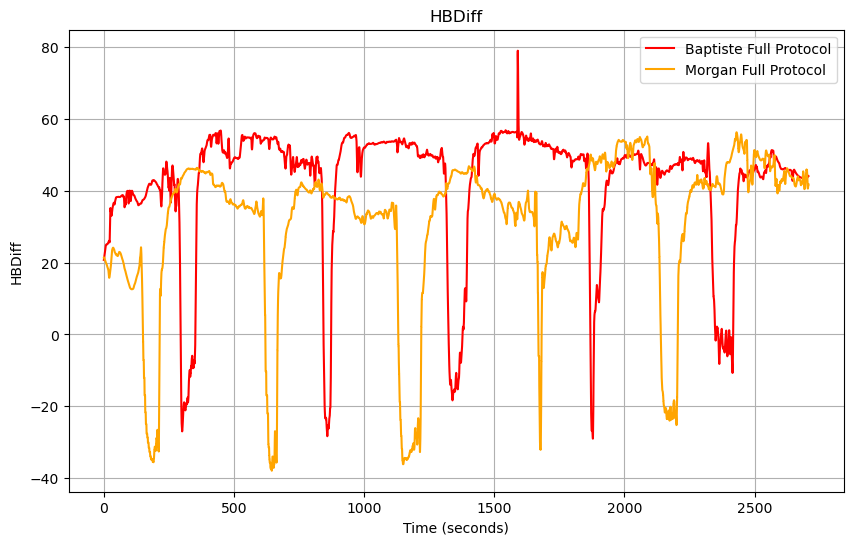

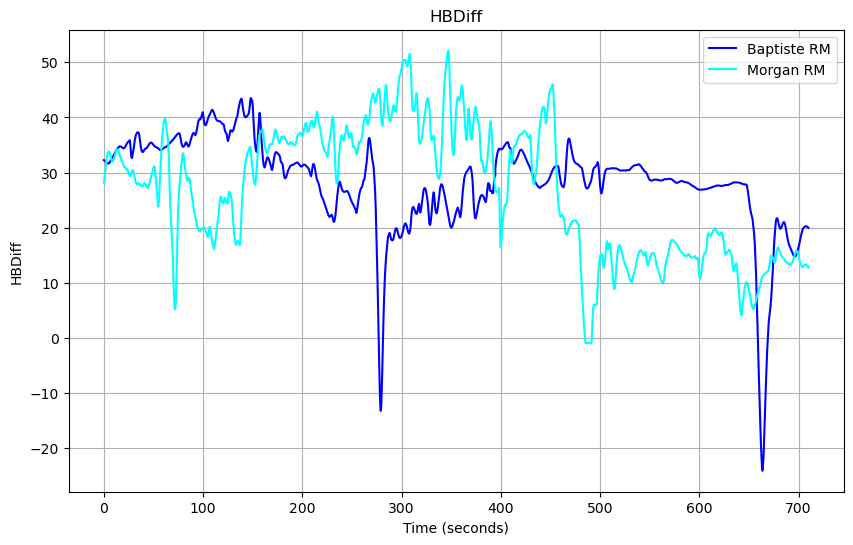

In [77]:
# Import data
bRM = pd.read_csv('Data\\100session_20260204_150203.csv', skiprows=61)
mRM = pd.read_csv('Data\\100session_20260204_150203.csv', skiprows=61)
b = pd.read_csv('Data\\session_20260204_151541.csv', skiprows=61)
m = pd.read_csv('Data\\session_20260204_151541.csv', skiprows=61)

cols_b = [0, 14]
cols_m = [0, 4]

hbdiff_bRM = bRM.iloc[:, cols_b].to_numpy()
hbdiff_mRM = mRM.iloc[:, cols_m].to_numpy()
hbdiff_b = b.iloc[:, cols_b].to_numpy()
hbdiff_m = m.iloc[:, cols_m].to_numpy()

# Plotting of the difference in hemoglobin HBDiff
plt.figure(figsize=(10, 6))
plt.plot(hbdiff_b[:, 0], hbdiff_b[:, 1], label='Baptiste Full Protocol', color='red')
plt.plot(hbdiff_m[:, 0], hbdiff_m[:, 1], label='Morgan Full Protocol', color='orange')
plt.title('HBDiff')
plt.xlabel('Time (seconds)')
plt.ylabel('HBDiff')
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(hbdiff_bRM[:, 0], hbdiff_bRM[:, 1], label='Baptiste RM', color='blue')
plt.plot(hbdiff_mRM[:, 0], hbdiff_mRM[:, 1], label='Morgan RM', color='cyan')
plt.title('HBDiff')
plt.xlabel('Time (seconds)')
plt.ylabel('HBDiff')
plt.legend()
plt.grid()
plt.show()

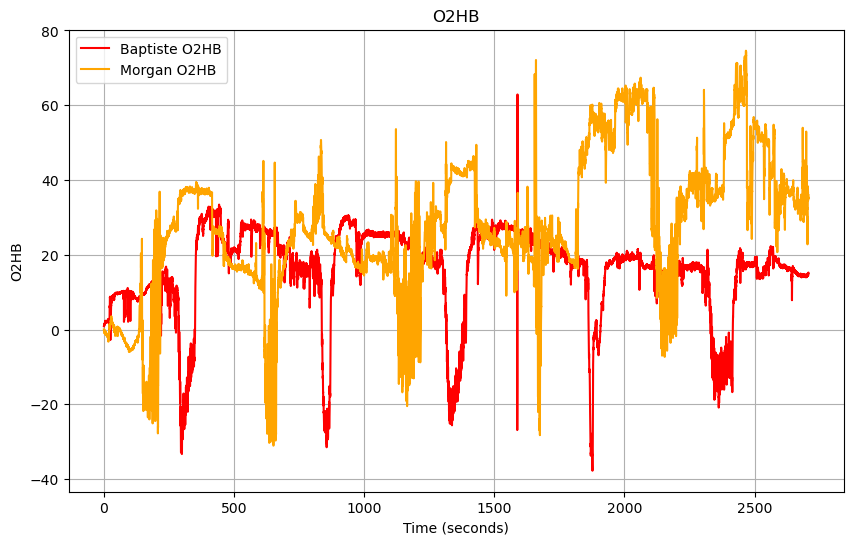

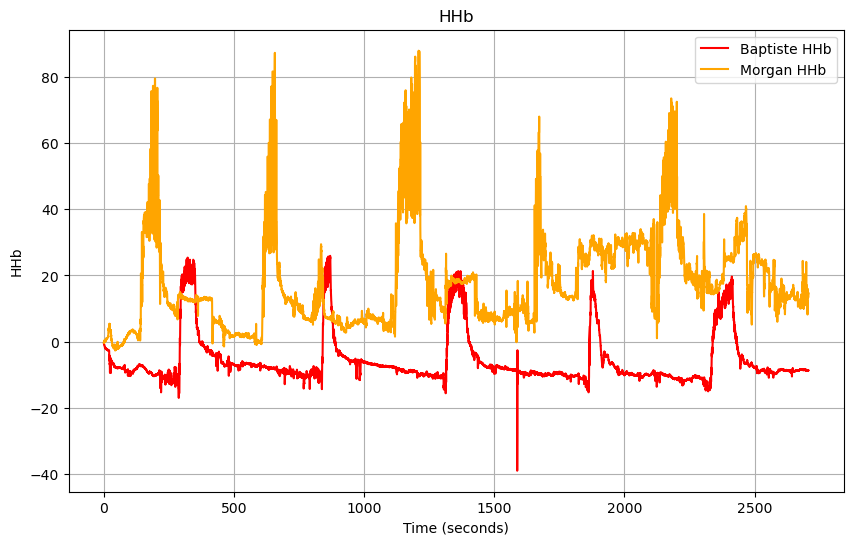

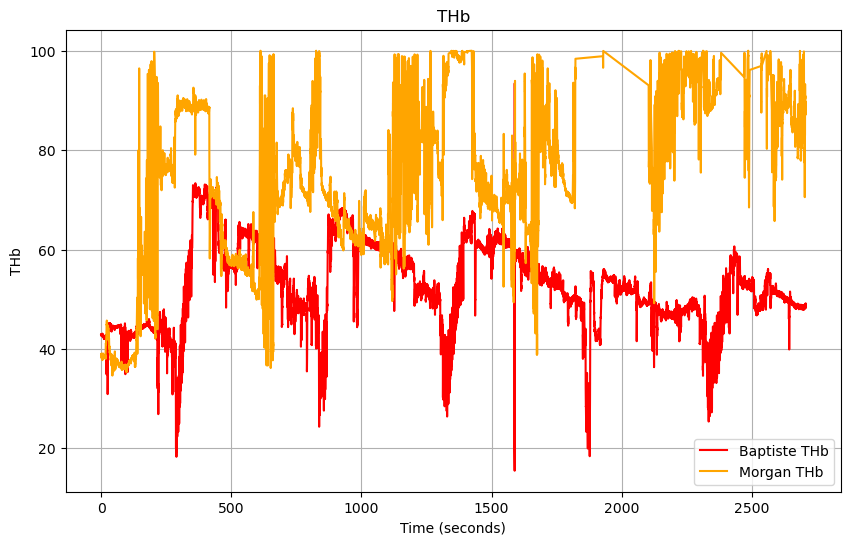

In [78]:
# Visualize the other variables: O2HB unfiltered (cols 8 (m) and 18 (b)), HHb unfiltered (cols 9 (m) and 19 (b)), THb unfiltered (cols 10 (m) and 20 (b))
# The columns for O2HB, HHb, and THb are as follows:
col_O2HB_b = [0, 18]
col_O2HB_m = [0, 8]
col_HHb_b = [0, 19]
col_HHb_m = [0, 9]
col_THb_b = [0, 20]
col_THb_m = [0, 10]

# Extract the data for O2HB, HHb, and THb for both Baptiste and Morgan
O2HB_b = b.iloc[:, col_O2HB_b].to_numpy()
O2HB_m = m.iloc[:, col_O2HB_m].to_numpy()
HHb_b = b.iloc[:, col_HHb_b].to_numpy()
HHb_m = m.iloc[:, col_HHb_m].to_numpy()
THb_b = b.iloc[:, col_THb_b].to_numpy()
THb_m = m.iloc[:, col_THb_m].to_numpy()

# Remove artefacts from the data (e.g., values above 100 or below -40)
O2HB_b = O2HB_b[(O2HB_b[:, 1] < 100) & (O2HB_b[:, 1] > -40)]
O2HB_m = O2HB_m[(O2HB_m[:, 1] < 100) & (O2HB_m[:, 1] > -40)]
HHb_b = HHb_b[(HHb_b[:, 1] < 100) & (HHb_b[:, 1] > -40)]
HHb_m = HHb_m[(HHb_m[:, 1] < 100) & (HHb_m[:, 1] > -40)]
THb_b = THb_b[(THb_b[:, 1] < 100) & (THb_b[:, 1] > 10)]
THb_m = THb_m[(THb_m[:, 1] < 100) & (THb_m[:, 1] > -40)]

# Plotting of O2HB, HHb, and THb for both Baptiste and Morgan
plt.figure(figsize=(10, 6))
plt.plot(O2HB_b[:, 0], O2HB_b[:, 1], label='Baptiste O2HB', color='red')
plt.plot(O2HB_m[:, 0], O2HB_m[:, 1], label='Morgan O2HB', color='orange')
plt.title('O2HB')
plt.xlabel('Time (seconds)')
plt.ylabel('O2HB')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HHb_b[:, 0], HHb_b[:, 1], label='Baptiste HHb', color='red')
plt.plot(HHb_m[:, 0], HHb_m[:, 1], label='Morgan HHb', color='orange')
plt.title('HHb')
plt.xlabel('Time (seconds)')
plt.ylabel('HHb')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(THb_b[:, 0], THb_b[:, 1], label='Baptiste THb', color='red')
plt.plot(THb_m[:, 0], THb_m[:, 1], label='Morgan THb', color='orange')
plt.title('THb')
plt.xlabel('Time (seconds)')
plt.ylabel('THb')
plt.legend()
plt.grid()
plt.show()


## Signal choice
We will use HbDiff, as it seems to be the clearest signal around the sets. Also because it was shown to be consistent to at least the HHb approach (Paternoster *et* Seiberl, 2022, https://doi.org/10.3390/app12052272). We will not apply a smoothing for the $m\dot VO_{2}$ calculation because HbDiff slopes seem clean enough, and that smoothing means also reducing the time series information.

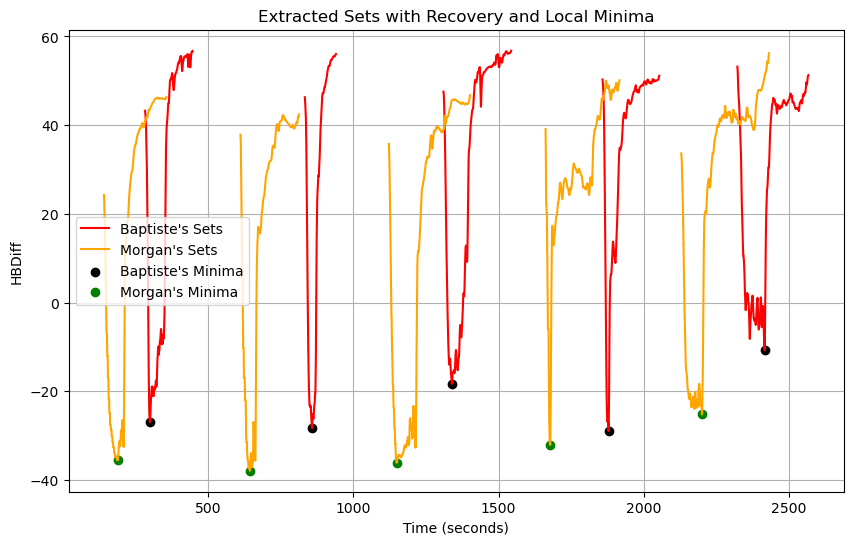

In [79]:
# Define each set according to the starts annotated in the image (last local maxima around them) and the first local maxima in HBdiff recovery (end) (manually spotted)
b50 = hbdiff_b[(hbdiff_b[:, 0] > 284.04) & (hbdiff_b[:, 0] < 448.16)]
b70 = hbdiff_b[(hbdiff_b[:, 0] > 833.56) & (hbdiff_b[:, 0] < 941.29)]
b30 = hbdiff_b[(hbdiff_b[:, 0] > 1310.60) & (hbdiff_b[:, 0] < 1543.44)]
b90 = hbdiff_b[(hbdiff_b[:, 0] > 1857.74) & (hbdiff_b[:, 0] < 2052.75)]
b10 = hbdiff_b[(hbdiff_b[:, 0] > 2321.35) & (hbdiff_b[:, 0] < 2566)]

m50 = hbdiff_m[(hbdiff_m[:, 0] > 142.6) & (hbdiff_m[:, 0] < 357.55)]
m70 = hbdiff_m[(hbdiff_m[:, 0] > 612.35) & (hbdiff_m[:, 0] < 813.63)]
m30 = hbdiff_m[(hbdiff_m[:, 0] > 1122.86) & (hbdiff_m[:, 0] < 1402.35)]
m90 = hbdiff_m[(hbdiff_m[:, 0] > 1661.74) & (hbdiff_m[:, 0] < 1916.25)]
m10 = hbdiff_m[(hbdiff_m[:, 0] > 2128.26) & (hbdiff_m[:, 0] < 2430.56)]

# Lists
b_sets = [b10, b30, b50, b70, b90]
m_sets = [m10, m30, m50, m70, m90]

# Starting points of each set
b_starts = [b10[0, 0], b30[0, 0], b50[0, 0], b70[0, 0], b90[0, 0]]
m_starts = [m10[0, 0], m30[0, 0], m50[0, 0], m70[0, 0], m90[0, 0]]

# Continuous arrays
b_sets_continuous = np.concatenate(b_sets)
m_sets_continuous = np.concatenate(m_sets)

# Find local minima
min_b_indices = find_peaks(-b_sets_continuous[:, 1], prominence=15, distance=1000)[0]
min_m_indices = find_peaks(-m_sets_continuous[:, 1], prominence=15, distance=1000)[0]


# Plot the extracted sets for both Baptiste and Morgan
plt.figure(figsize=(10, 6))
for set in b_sets:
    plt.plot(set[:, 0], set[:, 1], color='red', label="Baptiste's Sets" if set is b_sets[0] else "")
for set in m_sets:
    plt.plot(set[:, 0], set[:, 1], color='orange', label="Morgan's Sets" if set is m_sets[0] else "")
plt.scatter(b_sets_continuous[min_b_indices, 0], b_sets_continuous[min_b_indices, 1], color='black', label="Baptiste's Minima")
plt.scatter(m_sets_continuous[min_m_indices, 0], m_sets_continuous[min_m_indices, 1], color='green', label="Morgan's Minima")
plt.title('Extracted Sets with Recovery and Local Minima')
plt.xlabel('Time (seconds)')
plt.ylabel('HBDiff')
plt.legend()
plt.grid()
plt.show()


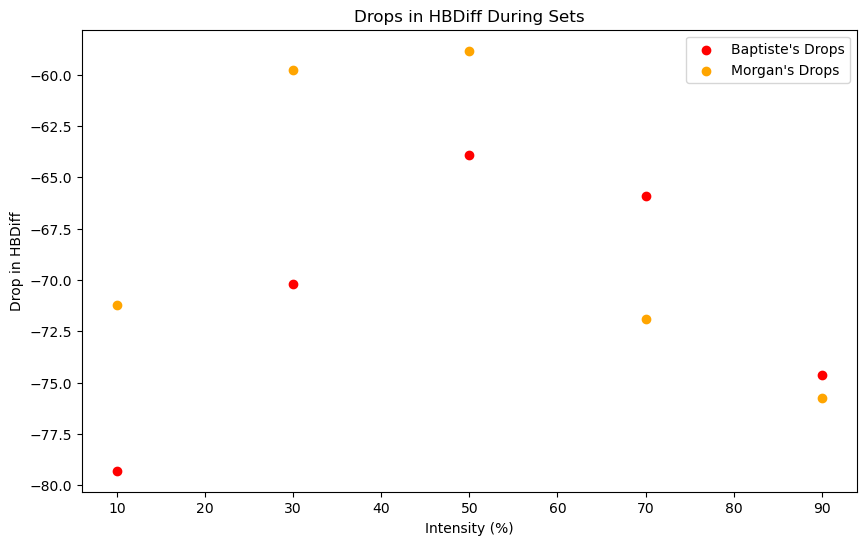

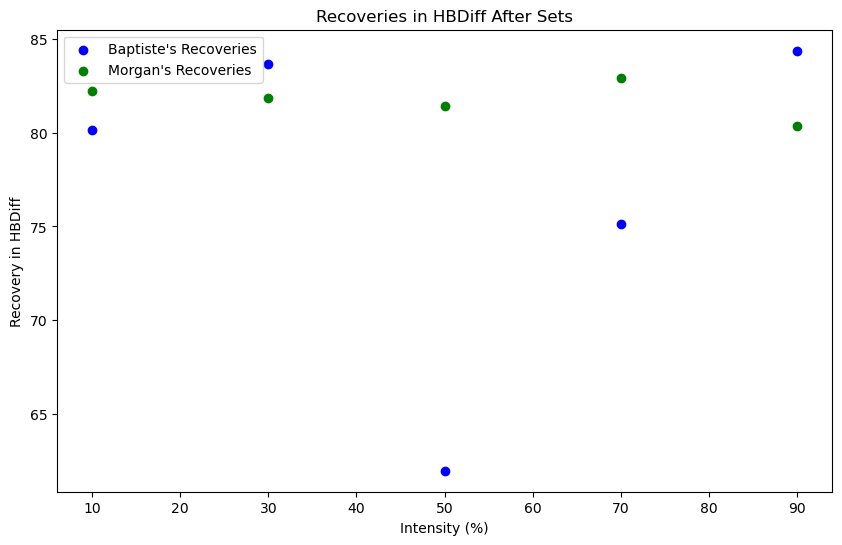

In [80]:
# Evaluate the magnitude of the drop in HBDiff during each set and the recovery after each set (e.g., difference between the minimum HBDiff during the set and the HBDiff at the end of the recovery period)

intensities_time = [50, 70, 30, 90, 10]  # Intensities corresponding to the order of the sets

# Drops
b_drops = []
m_drops = []
for set in b_sets:
    drop = np.min(set[:, 1]) - set[0, 1]  # Minimum HBDiff during the set minus first HBDiff
    b_drops.append(drop)
for set in m_sets:
    drop = np.min(set[:, 1]) - set[0, 1]  # Minimum HBDiff during the set minus first HBDiff
    m_drops.append(drop)

# Recoveries
b_recoveries = []
m_recoveries = []
for set in b_sets:
    recovery = set[-1, 1] - np.min(set[:, 1])  # Last HBDiff in the set minus minimum HBDiff during the set
    b_recoveries.append(recovery)
for set in m_sets:
    recovery = set[-1, 1] - np.min(set[:, 1])  # Last HBDiff in the set minus minimum HBDiff during the set
    m_recoveries.append(recovery)

# Associate drops and recoveries with intensities
b_results = list(zip(intensities_time, b_drops, b_recoveries))
m_results = list(zip(intensities_time, m_drops, m_recoveries))

# Plot drops and recoveries according to the intensities
plt.figure(figsize=(10, 6))
plt.scatter(intensities_time, b_drops, marker='o', label="Baptiste's Drops", color='red')
plt.scatter(intensities_time, m_drops, marker='o', label="Morgan's Drops", color='orange')
plt.title('Drops in HBDiff During Sets')
plt.xlabel('Intensity (%)')
plt.ylabel('Drop in HBDiff')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(intensities_time, b_recoveries, marker='o', label="Baptiste's Recoveries", color='blue')
plt.scatter(intensities_time, m_recoveries, marker='o', label="Morgan's Recoveries", color='green')
plt.title('Recoveries in HBDiff After Sets')
plt.xlabel('Intensity (%)')
plt.ylabel('Recovery in HBDiff')
plt.legend()
plt.show()

## Observations on raw data
We removed the latency part of the sets so that we directly begin with the decreasing HbDiff. We can make three major observations out of these first simple analyses:

1. HbDiff decreases as multiple repetitions are performed (the decrement happens on more than 10 seconds for each intensity).
2. The magnitude of HbDiff initial drop seems to be influenced by the intensity of the exercise, with the extremes (very low or very high intensities) inducing greater drops. The magnitude of recovery does not seem to reveal particular patterns in function of intensity.
3. HbDiff recovers even when repetitions are still being done (little decrements in the HbDiff recovery that are consistent between both participants for each set).

A possible explanation that one could make about the second point would be that the lighter loads allow for reps to be executed faster, which means that the muscle would need more dioxygen (to retrieve the fill the dioxygen debt) in reason of the number of contractions realised at a given time. Indeed, we did not control for the speed of execution, participants could have inconsciously fastened the pace at these intensities to execute a higher number of repetitions in the least possible time, although it was not the instruction. On the other hand, the heavier loads require more force development and time to be executed, which is translated into greater motor units recruitment and longer time under contraction, and thus potentially more oxygen debt. The mild intensities could then be a better compromise in terms of metabolic cost between amount of force needed and contraction's frequency.

We did not perform arterial occlusions after the sets, so we cannot estimate the $m\dot VO_{2}$ recovery rate (Adami *et* Rossiter, 2017, https://doi.org/10.1152/japplphysiol.00445.2017). However, HbDiff already captures indirect information: that is, during what we call "recovery", the O2Hb increase or HHb decrease, or both. O2Hb increase can be due to two things: central processes that are more recruited or mitochondria that stop using $O_{2}$. HHb decrease can be due to the same processes. These are contradictory, that is why we will not adventure ourselves in comparing time characteristics of the HbDiff recovery.

In [81]:
# # Loess smoothing of the HBDiff data
# from statsmodels.nonparametric.smoothers_lowess import lowess
# b_sets_smooth = [None] * len(b_sets)
# for i, set in enumerate(b_sets):
#     b_sets_smooth[i] = lowess(set[:, 1], set[:, 0], frac=0.05)


# m_sets_smooth = [None] * len(m_sets)
# for i, set in enumerate(m_sets):
#     m_sets_smooth[i] = lowess(set[:, 1], set[:, 0], frac=0.05)


# # Plotting of the smoothed HBDiff data
# plt.figure(figsize=(10, 6))
# for i, set in enumerate(b_sets_smooth):
#     plt.plot(set[:, 0], set[:, 1], label=f'Baptiste Sets Smoothed' if i == 0 else "", color='red')
# for i, set in enumerate(m_sets_smooth):
#     plt.plot(set[:, 0], set[:, 1], label=f'Morgan Sets Smoothed' if i == 0 else "", color='orange')
# plt.title('Smoothed HBDiff')
# plt.xlabel('Time (seconds)')
# plt.ylabel('HBDiff')
# plt.legend()
# plt.grid()
# plt.show()

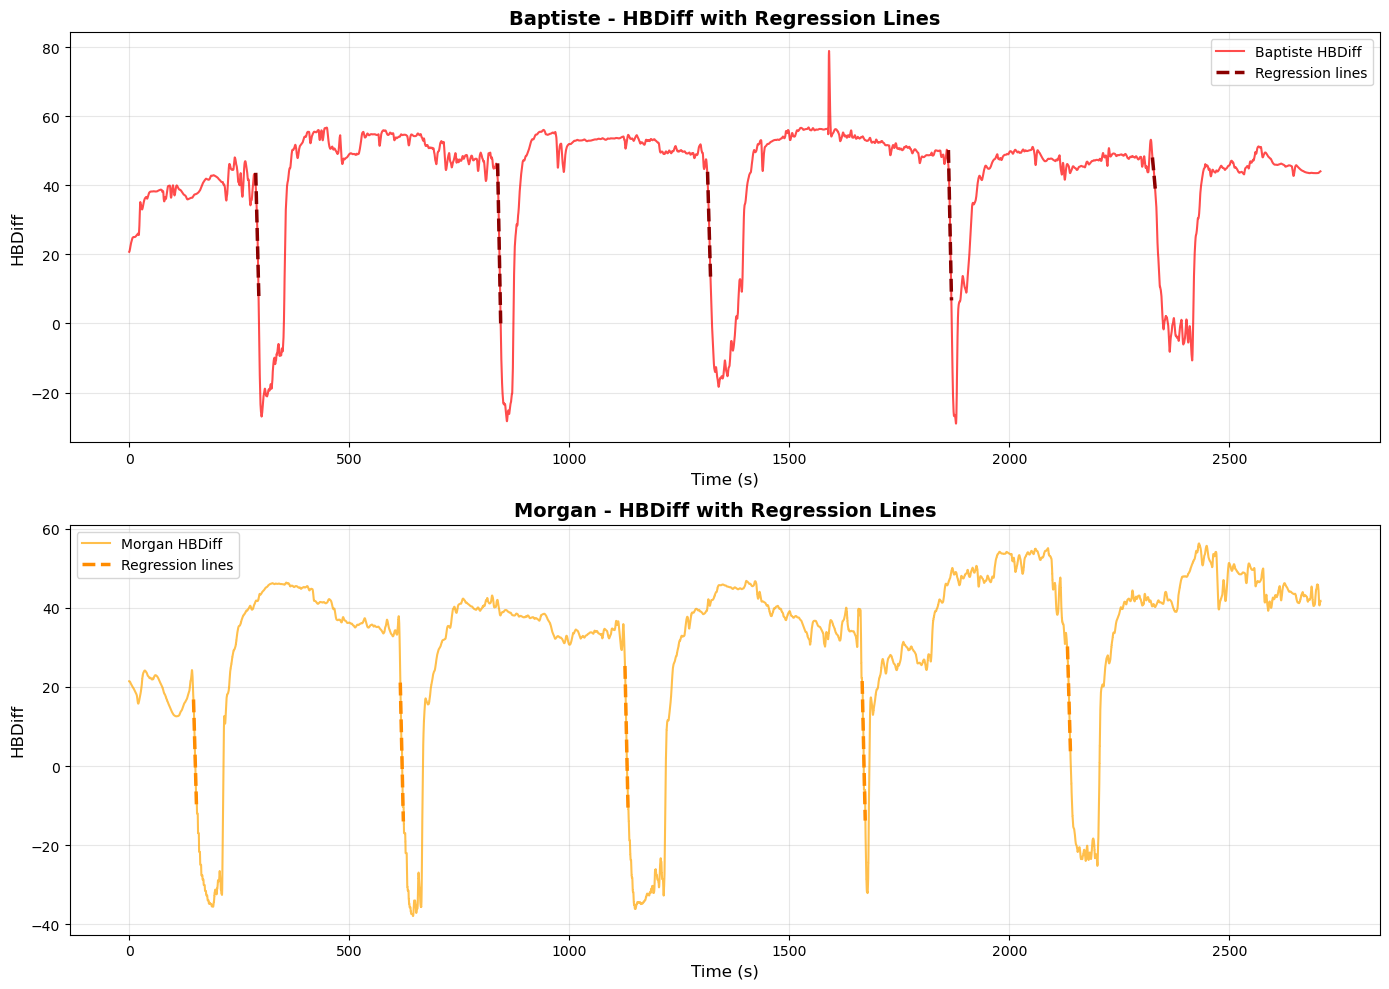

In [82]:
# Extract slopes and intercepts for computing $m\dot VO_{2}$ and plotting regression lines
def extract_slopes_and_intercepts(hbdiff, peaks):
    slopes = []
    intercepts = []
    for peak in peaks:
        x = hbdiff[(hbdiff[:, 0] > peak + 3.5) & (hbdiff[:, 0] < peak + 10.5), 0]  # Choice of 3.5-10.5 guided by visual inspection of the data
        y = hbdiff[(hbdiff[:, 0] > peak + 3.5) & (hbdiff[:, 0] < peak + 10.5), 1]
        A = np.vstack([x, np.ones(len(x))]).T
        m, c = np.linalg.lstsq(A, y, rcond=None)[0]
        slopes.append(m)
        intercepts.append(c)
    return slopes, intercepts

slopes_b, intercepts_b = extract_slopes_and_intercepts(b_sets_continuous, b_starts)
slopes_m, intercepts_m = extract_slopes_and_intercepts(m_sets_continuous, m_starts)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot Baptiste's data
ax1.plot(hbdiff_b[:, 0], hbdiff_b[:, 1], label='Baptiste HBDiff', color='red', alpha=0.7)

# Overlay regression lines for Baptiste
for i, (start, slope, intercept) in enumerate(zip(b_starts, slopes_b, intercepts_b)):
    x_line = np.array([start + 3.5, start + 10.5])
    y_line = slope * x_line + intercept
    ax1.plot(x_line, y_line, '--', color='darkred', linewidth=2.5, 
             label=f'Regression lines' if i == 0 else '')

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('HBDiff', fontsize=12)
ax1.set_title('Baptiste - HBDiff with Regression Lines', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot Morgan's data
ax2.plot(hbdiff_m[:, 0], hbdiff_m[:, 1], label='Morgan HBDiff', color='orange', alpha=0.7)

# Overlay regression lines for Morgan
for i, (start, slope, intercept) in enumerate(zip(m_starts, slopes_m, intercepts_m)):
    x_line = np.array([start + 3.5, start + 10.5])
    y_line = slope * x_line + intercept
    ax2.plot(x_line, y_line, '--', color='darkorange', linewidth=2.5, 
             label=f'Regression lines' if i == 0 else '')

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('HBDiff', fontsize=12)
ax2.set_title('Morgan - HBDiff with Regression Lines', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [83]:
intensities = [10, 30, 50, 70, 90]

# Convert slopes to $m\dot VO_{2}$
mVO2_b = [(((abs(slope) / 2) * 60) * 4 / (10 * 1.04)) * 22.4 / 1000 for slope in slopes_b]
mVO2_m = [(((abs(slope) / 2) * 60) * 4 / (10 * 1.04)) * 22.4 / 1000 for slope in slopes_m]

# Dataframe of the slopes with the corresponding set intensities
mVO2_i_b = pd.DataFrame({
    'Intensity (%)': intensities,
    "Baptiste mV'O2": mVO2_b,})

mVO2_i_m = pd.DataFrame({
    'Intensity (%)': intensities,
    "Morgan mV'O2": mVO2_m,})

# Dataframe of the slopes with the corresponding start times
mVO2_t_b = pd.DataFrame({
    'Time (s)': b_starts,
    "Baptiste mV'O2": mVO2_b,})

mVO2_t_m = pd.DataFrame({
    'Time (s)': m_starts,
    "Morgan mV'O2": mVO2_m,})

print(mVO2_i_b)
print(mVO2_i_m)
print(mVO2_t_b)
print(mVO2_t_m)

   Intensity (%)  Baptiste mV'O2
0             10        0.365308
1             30        1.163952
2             50        1.319678
3             70        1.726901
4             90        1.607457
   Intensity (%)  Morgan mV'O2
0             10      1.005579
1             30      1.333066
2             50      1.029539
3             70      1.294938
4             90      1.301549
   Time (s)  Baptiste mV'O2
0   2321.47        0.365308
1   1310.61        1.163952
2    284.05        1.319678
3    833.65        1.726901
4   1857.92        1.607457
   Time (s)  Morgan mV'O2
0   2128.35      1.005579
1   1122.95      1.333066
2    142.65      1.029539
3    612.45      1.294938
4   1661.89      1.301549


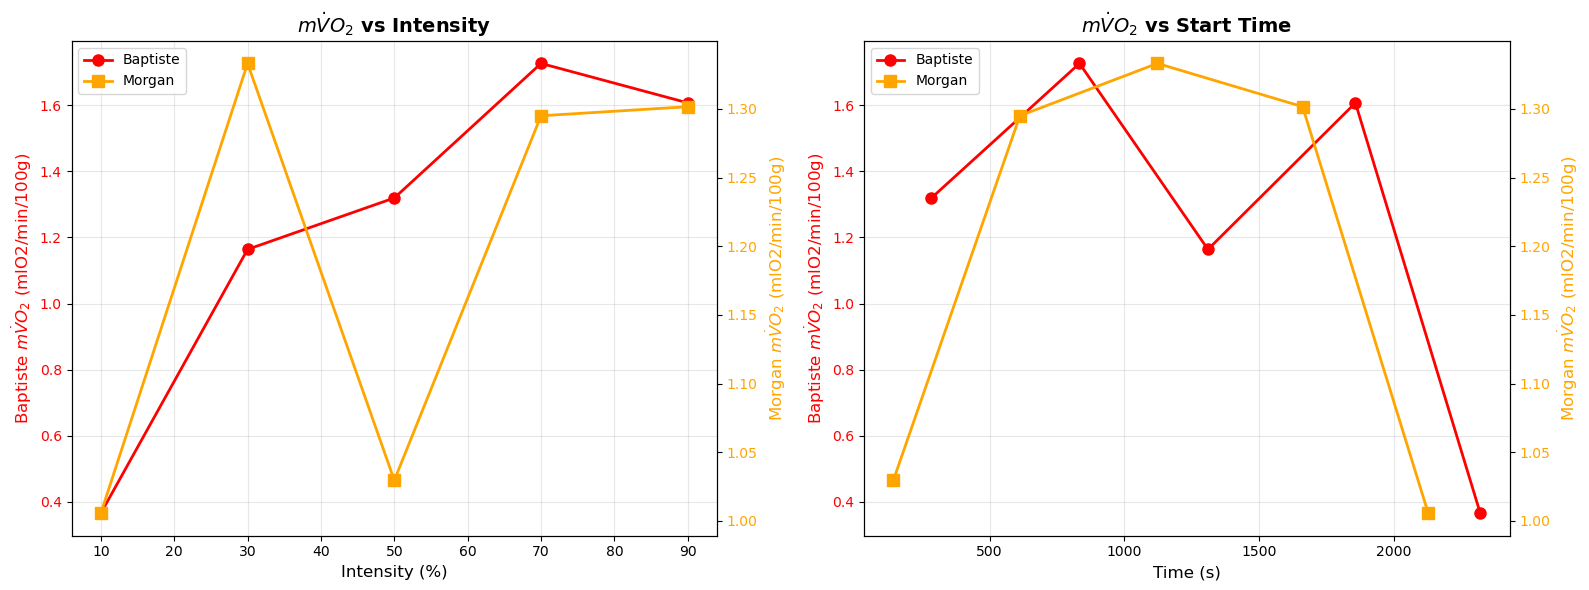

In [84]:
# Create subplots with dual y-axes for comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


# Subplot 1: mV'O2 vs Intensity with dual y-axes
ax1_twin = ax1.twinx()

# Plot Baptiste on left y-axis
line1 = ax1.plot(intensities, mVO2_b, 'o-', color='red', linewidth=2, markersize=8, label='Baptiste')
ax1.set_xlabel('Intensity (%)', fontsize=12)
ax1.set_ylabel('Baptiste $m\dot VO_{2}$ (mlO2/min/100g)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, alpha=0.3)

# Plot Morgan on right y-axis
line2 = ax1_twin.plot(intensities, mVO2_m, 's-', color='orange', linewidth=2, markersize=8, label='Morgan')
ax1_twin.set_ylabel('Morgan $m\dot VO_{2}$ (mlO2/min/100g)', color='orange', fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor='orange')

ax1.set_title('$m\dot VO_{2}$ vs Intensity', fontsize=14, fontweight='bold')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# Subplot 2: mV'O2 vs Time with dual y-axes
ax2_twin = ax2.twinx()

# Sort data by time for chronological line plotting
b_time_sorted = sorted(zip(b_starts, mVO2_b))
m_time_sorted = sorted(zip(m_starts, mVO2_m))
b_starts_sorted, mVO2_b_sorted = zip(*b_time_sorted)
m_starts_sorted, mVO2_m_sorted = zip(*m_time_sorted)

# Plot Baptiste on left y-axis
line3 = ax2.plot(b_starts_sorted, mVO2_b_sorted, 'o-', color='red', linewidth=2, markersize=8, label='Baptiste')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Baptiste $m\dot VO_{2}$ (mlO2/min/100g)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(True, alpha=0.3)

# Plot Morgan on right y-axis
line4 = ax2_twin.plot(m_starts_sorted, mVO2_m_sorted, 's-', color='orange', linewidth=2, markersize=8, label='Morgan')
ax2_twin.set_ylabel('Morgan $m\dot VO_{2}$ (mlO2/min/100g)', color='orange', fontsize=12)
ax2_twin.tick_params(axis='y', labelcolor='orange')

ax2.set_title('$m\dot VO_{2}$ vs Start Time', fontsize=14, fontweight='bold')

# Combine legends
lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc='upper left')

plt.tight_layout()
plt.show()


## Observations on $m\dot VO_{2}$
We controlled for the effect of sets' order by having adjacent "opposit" intensities and by looking at the $m\dot VO_{2}$ of each set's first repetitions in function of time. We do not see a particular increasing or decreasing trend that could have revealed a bias due to previous sets execution. The 7-min rest between sets thus seems sufficient for near-complete recovery in these two participants.

These analyses show that intensity seems to have differentiated effects on the two participants' $O_{2}$ muscle consumption. Nonetheless, we can still notice the two last intensities that induced two close $m\dot VO_{2}$ values for both subjects (be wary of the y-axes scales). Similarly, the 10 to 30 % intensities seem to drastically differ in $O_{2}$ consumption rate. Because we do not have measured the precise sets' timings (which could have been done with the accelerometric data of the other sensor), we cannot estimate each set total energy expenditure by multiplying this measure of $m\dot VO_{2}$ with the set time $t$. It would have been interesting to see which intensities, in this task of performing until exhaustion, yield the most overall energy expenditure. This eastimation could guide training by pointing at the intensities that are the most metabolic compared to the least, while having the same ending: failure at exercise.

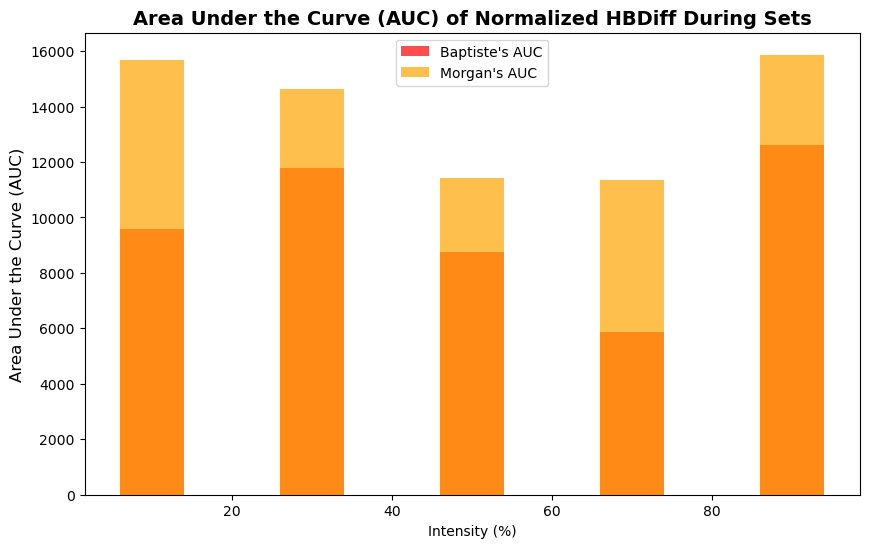

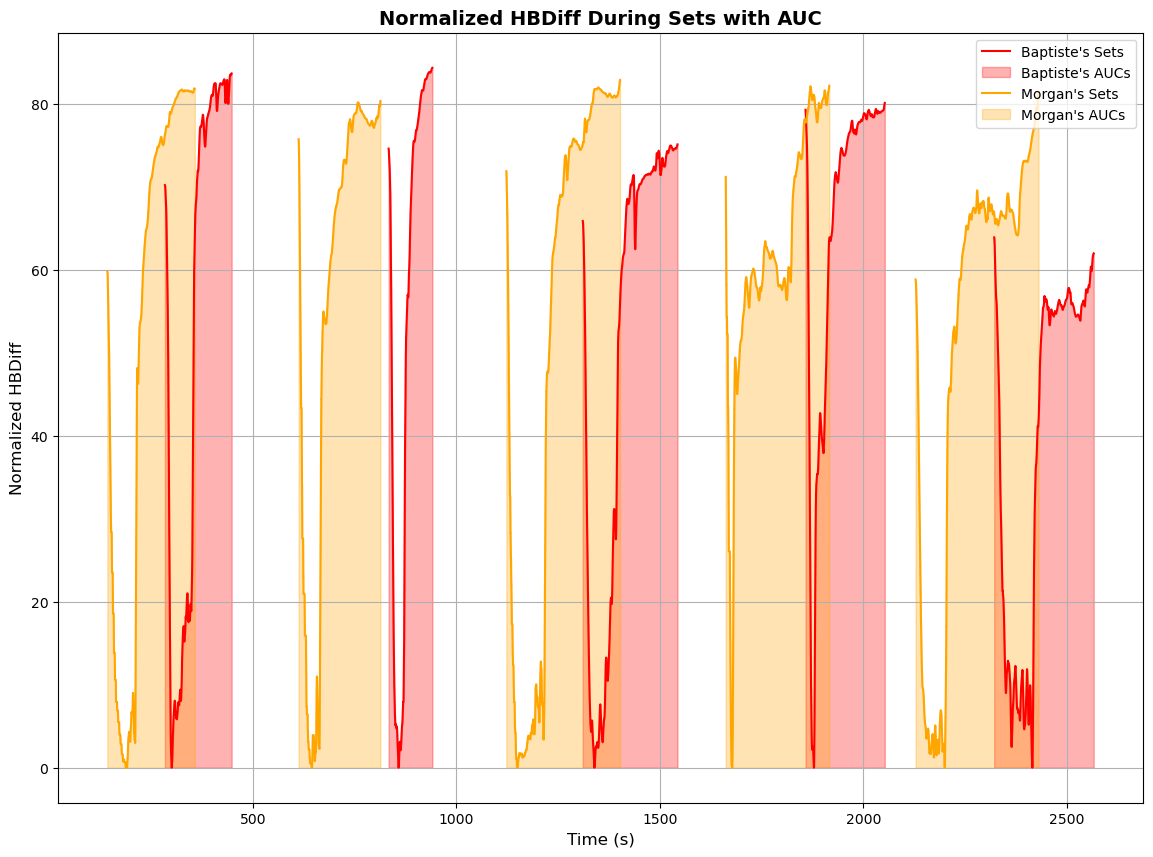

In [85]:
# Normalize the HBdiff data to the minimum HBdiff during the set (as 0) for each set for both Baptiste and Morgan
b_sets_normalized = []
for set in b_sets:
    min_hbdiff = np.min(set[:, 1])
    normalized_set = set.copy()
    normalized_set[:, 1] = set[:, 1] - min_hbdiff
    b_sets_normalized.append(normalized_set)

m_sets_normalized = []
for set in m_sets:
    min_hbdiff = np.min(set[:, 1])
    normalized_set = set.copy()
    normalized_set[:, 1] = set[:, 1] - min_hbdiff
    m_sets_normalized.append(normalized_set)

# Calculate and plot the area under the curve (AUC) for each set for both Baptiste and Morgan
b_aucs = []
for set in b_sets_normalized:
    auc = simpson(set[:, 1], set[:, 0])
    b_aucs.append(auc)

m_aucs = []
for set in m_sets_normalized:
    auc = simpson(set[:, 1], set[:, 0])
    m_aucs.append(auc)

plt.figure(figsize=(10, 6))
plt.bar(intensities, b_aucs, width=8, alpha=0.7, label="Baptiste's AUC", color='red')
plt.bar(intensities, m_aucs, width=8, alpha=0.7, label="Morgan's AUC", color='orange')
plt.xlabel('Intensity (%)')
plt.ylabel('Area Under the Curve (AUC)', fontsize=12)
plt.title('Area Under the Curve (AUC) of Normalized HBDiff During Sets', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# Visualize the AUCs in the HBdiff plots for each set for both Baptiste and Morgan
plt.figure(figsize=(14, 10))
for i, set in enumerate(b_sets_normalized):
    plt.plot(set[:, 0], set[:, 1], color='red', label=f"Baptiste's Sets" if i == 0 else "")
    plt.fill_between(set[:, 0], set[:, 1], alpha=0.3, color='red', label=f"Baptiste's AUCs" if i == 0 else "")
for i, set in enumerate(m_sets_normalized):
    plt.plot(set[:, 0], set[:, 1], color='orange', label=f"Morgan's Sets" if i == 0 else "")
    plt.fill_between(set[:, 0], set[:, 1], alpha=0.3, color='orange', label=f"Morgan's AUCs" if i == 0 else "")
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Normalized HBDiff', fontsize=12)
plt.title('Normalized HBDiff During Sets with AUC', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid()
plt.show()


## Observations on AUC
The area under the curve of HbDiff calculation allows to estimate the time at which each subject, and according to each intensity, experienced a low O2Hb as compared to HHb.

Interestingly, this calculation shows similarities with the HbDiff initial magnitude of change (drop) computed earlier, except that it supports inverse hypotheses. Meaning, mild intensities induce more hemodynamics stress than low and high intensities. However, we should not forget that the AUC takes time into account (impulse). That is why one could hypothesize that mild intensities are less costly for a few repetitions, whereas for the whole to-exhaustion set and subsequent recovery, they are the most impactful on peripheral hemodynamics. Because the protocol yields a lot of limitations in itself, notably the uncontrol of execution speed, our results and hypotheses should be interpreted with great cautious.